In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

import geopandas as gpd
from shapely.geometry import Point
import numpy as np

import cartopy.io.img_tiles as cimgt
from shapely.geometry import Polygon, MultiPolygon
import matplotlib.patches as mpatches

import geopandas as gpd



In [2]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [3]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc45.hpc.ucar.edu/34172/proxy/8787/status,
Dashboard: /node/crhtc45.hpc.ucar.edu/34172/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.95:45529,Workers: 0
Dashboard: /node/crhtc45.hpc.ucar.edu/34172/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
# =====================================================
# USER SETTINGS
# =====================================================
data_dir = Path("/glade/derecho/scratch/rneale/IMERG/3hrly/0.25deg/")
file_pattern = "*.nc"

target_lat = -2.000
target_lon = 29.294

target_lat = -1.671
target_lon = 29.66

# Options: "3hourly", "daily", "monthly"
output_frequency = "daily"

# Plot subset
plot_start = '2000-01-01'
plot_end   = '2025-09-30'

output_nc = "imerg_point_timeseries_2.nc"
output_csv = "imerg_point_timeseries_2.csv"


# =====================================================
# OPEN FILES
# =====================================================
files = sorted(data_dir.glob(file_pattern))

if len(files) == 0:
    raise FileNotFoundError("No NetCDF files found")



print('--- Reading Data ---')

def preprocess(ds):

    # Decode only true time coordinate
    ds["time"] = xr.decode_cf(ds[["time"]])["time"]

    # Drop unused vars
    ds = ds.drop_vars(
        ["date", "datesec", "yyyymmddhh"],
        errors="ignore"
    )

    # Keep only precip
    ds = ds[["precip"]]

    # Subset spatially immediately
    ds = ds.sel(
        lat=target_lat,
        lon=target_lon,
        method="nearest"
    )

    return ds

ds = xr.open_mfdataset(
    files,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    parallel=True,
    decode_times=False,
    chunks={"time": 240}
)



#def preprocess(ds):
#    ds["time"] = xr.decode_cf(ds[["time"]])["time"]
#    return ds

#ds = xr.open_mfdataset(
#    files,
#    preprocess=preprocess,
#    combine="by_coords",
#    parallel=True,
#    decode_times=False
#)

#ds = xr.open_mfdataset(
#    files,
#    combine="nested",
#    concat_dim="time",
#    parallel=True,
#    decode_times=False
#)



# Manually decode only the actual time coordinate
#ds["time"] = xr.decode_cf(
#    ds[["time"]]   # only decode the real time variable
#)["time"]



print(f"Opened {len(files)} files")

--- Reading Data ---
Opened 303 files


Requested: (-1.671, 29.66)
Nearest grid point: (-1.625, 29.625)
Created daily dataset


<xarray.DataArray 'precip' (time: 9253)> Size: 37kB
dask.array<setitem, shape=(9253,), dtype=float32, chunksize=(19,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 74kB 2000-06-01 2000-06-02 ... 2025-09-30
    lon      float64 8B 29.62
    lat      float64 8B -1.625
Attributes:
    long_name:       3-hour accumulated precipitation
    units:           mm/day
    source:          GPM IMERG V07B 3-hourly mean
    delta_t:         0000-00-00 03:00:00
    time_statistic:  mean

<xarray.DataArray 'precip' (time: 9253)> Size: 37kB
dask.array<setitem, shape=(9253,), dtype=float32, chunksize=(19,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 74kB 2000-06-01 2000-06-02 ... 2025-09-30
    lon      float64 8B 29.62
    lat      float64 8B -1.625
Attributes:
    long_name:       3-hour accumulated precipitation
    units:           mm/day
    source:          GPM IMERG V07B 3-hourly mean
    delta_t:         0000-00-00 03:00:00
    time_statistic:  mean

Saved CSV: imerg_point_timeseries_2.csv


HDF5-DIAG: Error detected in HDF5 (1.14.6) MPI-process 0:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/glade/work/rn

Saved NetCDF: imerg_point_timeseries_2.nc


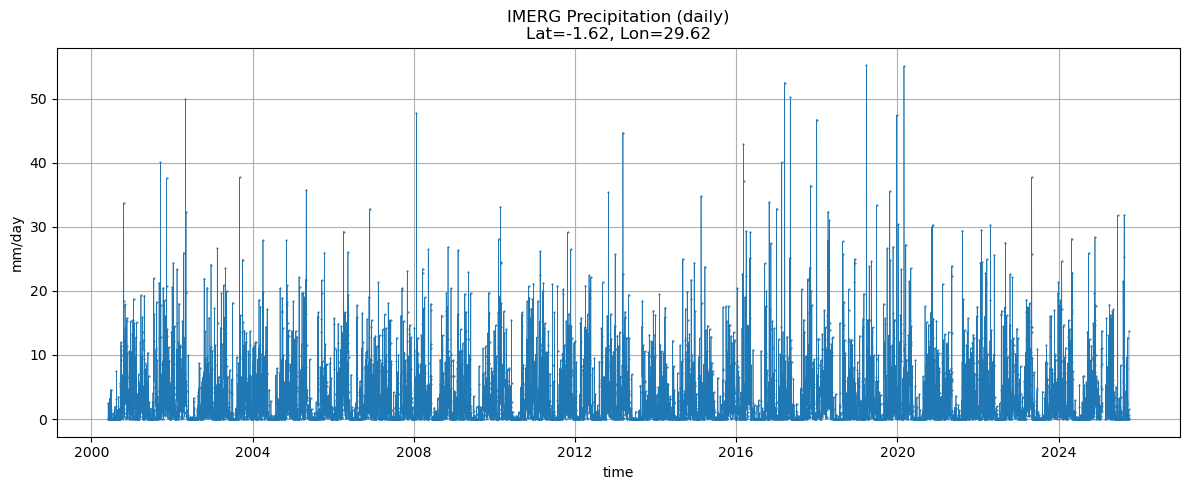

In [5]:
# =====================================================
# HANDLE LONGITUDE CONVENTION
# =====================================================
if ds.lon.max() > 180 and target_lon < 0:
    target_lon = target_lon % 360


# =====================================================
# EXTRACT NEAREST GRID POINT
# =====================================================
#point_ds = ds.sel(
#    lat=target_lat,
#    lon=target_lon,
#    method="nearest"
#)

precip_3hr_rate = ds["precip"].where(
    ds["precip"] != -9999.9
)

actual_lat = float(ds.lat.values)
actual_lon = float(ds.lon.values)

print(f"Requested: ({target_lat}, {target_lon})")
print(f"Nearest grid point: ({actual_lat}, {actual_lon})")


# =====================================================
# PREPARE PRECIP SERIES
# =====================================================
precip_3hr_rate = ds["precip"]

# Convert rate (mm/hr) → accumulated precip per timestep
precip_3hr_total = precip_3hr_rate * 3
precip_3hr_total.attrs["units"] = "mm per 3-hour period"
precip_3hr_total.attrs["long_name"] = "3-hour accumulated precipitation"


# =====================================================
# TEMPORAL AGGREGATION
# =====================================================
if output_frequency == "3hourly":
    precip_out = precip_3hr_rate.copy()
    output_units = "mm/hr"

elif output_frequency == "daily":
    precip_out = precip_3hr_total.resample(time="1D").sum()
    output_units = "mm/day"

elif output_frequency == "monthly":
    precip_out = precip_3hr_total.resample(time="1MS").sum()
    output_units = "mm/month"

else:
    raise ValueError(
        "output_frequency must be: "
        "'3hourly', 'daily', or 'monthly'"
    )

precip_out.attrs["units"] = output_units

print(f"Created {output_frequency} dataset")


# =====================================================
# PLOT SUBSET
# =====================================================
display(precip_out)

plot_data = precip_out.sel(
    time=slice(plot_start, plot_end)
)

display(plot_data)

plt.figure(figsize=(12,5))
plot_data.plot(marker="o",linewidth=0.5,markersize=0.5)

plt.title(
    f"IMERG Precipitation ({output_frequency})\n"
    f"Lat={actual_lat:.2f}, Lon={actual_lon:.2f}"
)

plt.ylabel(output_units)
plt.grid(True)
plt.tight_layout()



# =====================================================
# EXPORT DATAFRAME
# =====================================================
df = precip_out.to_dataframe().reset_index()
df.to_csv(output_csv, index=False)
print(f"Saved CSV: {output_csv}")


# =====================================================
# SAVE NETCDF
# =====================================================
out_ds = xr.Dataset(
    {
        "precip": precip_out
    }
)

out_ds.attrs = {
    "title": f"Extracted IMERG {output_frequency} precipitation time series",
    "requested_lat": target_lat,
    "requested_lon": target_lon,
    "actual_grid_lat": actual_lat,
    "actual_grid_lon": actual_lon,
    "grid_selection_method": "nearest neighbor",
    "source_dataset": ds.attrs.get("title"),
    "source_data": ds.attrs.get("source_data"),
    "original_creation_date": ds.attrs.get("creation_date"),
    "temporal_aggregation": output_frequency
}

out_ds.to_netcdf(output_nc)
print(f"Saved NetCDF: {output_nc}")

plt.savefig ('precip_ts.png')
plt.show()

--- Start ---
Map extent:
Latitude : -6.13 to 2.88
Longitude: 25.12 to 34.13
Grid point country: Rwanda
Kenya
Tanzania
Dem. Rep. Congo
Burundi
Rwanda
Uganda


<Figure size 1100x900 with 0 Axes>

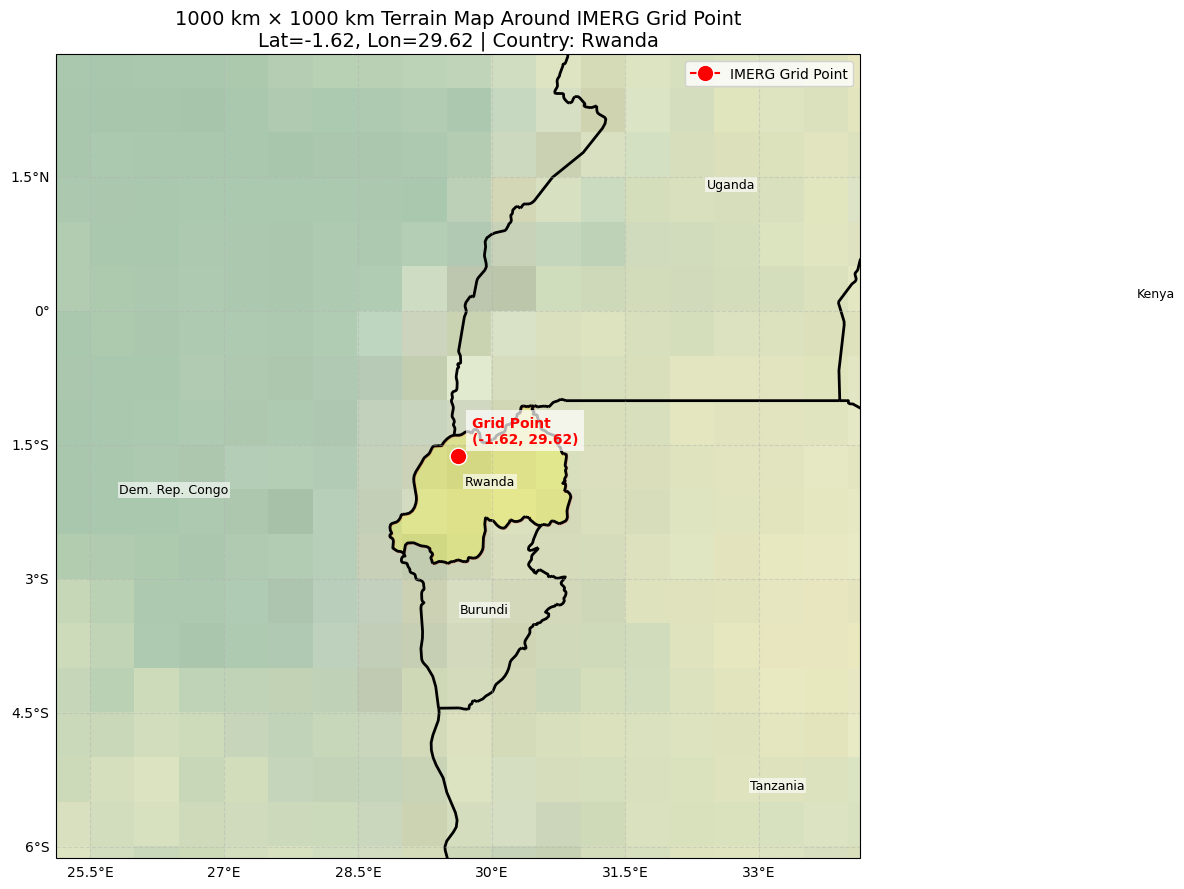

In [7]:
# ==========================================================
# TERRAIN MAP AROUND SELECTED IMERG GRID POINT
# ==========================================================


# ==========================================================
# DOMAIN SETTINGS
# ==========================================================
# Total domain = 1000 km x 1000 km
# (500 km from center in each direction)

print('--- Start ---')

half_width_km = 250

# Convert km -> degrees latitude
#lat_half_width_deg = half_width_km / 111.0

# Convert km -> degrees longitude
#lon_half_width_deg = (
#    half_width_km /
#    (111.0 * np.cos(np.deg2rad(actual_lat)))
#)

#lat_min = actual_lat - lat_half_width_deg
#lat_max = actual_lat + lat_half_width_deg

#lon_min = actual_lon - lon_half_width_deg
#lon_max = actual_lon + lon_half_width_deg


half_width_km = 500  # FULL 1000 km domain

lat_half_width_deg = half_width_km / 111.0
lon_half_width_deg = half_width_km / (111.0 * np.cos(np.deg2rad(actual_lat)))

lat_min = actual_lat - lat_half_width_deg
lat_max = actual_lat + lat_half_width_deg

lon_min = actual_lon - lon_half_width_deg
lon_max = actual_lon + lon_half_width_deg



print("Map extent:")
print(f"Latitude : {lat_min:.2f} to {lat_max:.2f}")
print(f"Longitude: {lon_min:.2f} to {lon_max:.2f}")


# ==========================================================
# LOAD COUNTRY SHAPEFILE
# ==========================================================

shpfilename = shpreader.natural_earth(
    resolution='10m',
    category='cultural',
    name='admin_0_countries'
)

world = gpd.read_file(shpfilename)


# =====================================================
# CLIP TO MAP REGION
# =====================================================
world_clip = world.cx[
    lon_min:lon_max,
    lat_min:lat_max
]

# ==========================================================
# FIND COUNTRY CONTAINING GRID POINT
# ==========================================================

# Convert longitude if needed
point_lon = actual_lon

if point_lon > 180:
    point_lon -= 360

point = Point(point_lon, actual_lat)

country_match = world[world.contains(point)]

if len(country_match) > 0:
    country_name0 = country_match.iloc[0]["ADMIN"]
    print(f"Grid point country: {country_name0}")
else:
    country_name = "Ocean / Unknown"
    print("Point not located inside a country polygon.")


# ==========================================================
# CREATE MAP
# ==========================================================

fig = plt.figure(figsize=(11, 9))

# Terrain background tiles
#terrain = cimgt.Stamen('terrain-background')

#terrain = cimgt.StadiaMapsTiles(
#    style="stamen_terrain_background"
#)

#ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent
#ax.set_extent(
#    [lon_min, lon_max, lat_min, lat_max],
#    crs=ccrs.PlateCarree()
#)

# ==========================================================
# CREATE MAP
# ==========================================================

fig = plt.figure(figsize=(11, 9))

ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent
ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# ==========================================================
# ADD TERRAIN / SHADED RELIEF
# ==========================================================

# Optional: add land/ocean styling
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.2)








# ==========================================================
# ADD TERRAIN
# ==========================================================

#ax.add_image(terrain, 8)

# ==========================================================
# ADD FEATURES
# ==========================================================

#ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle="-", linewidth=2)

#ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="0.85", zorder=0)
#ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)

ax.stock_img()

#try:
#    ax.add_feature(cfeature.STATES, linestyle=":", alpha=0.5)
#except:
#    pass

# ==========================================================
# HIGHLIGHT COUNTRY
# ==========================================================

if len(country_match) > 0:

    country_match.plot(
        ax=ax,
        facecolor="yellow",
        edgecolor="red",
        linewidth=2,
        alpha=0.25,
        transform=ccrs.PlateCarree()
    )

# ==========================================================
# PLOT GRID POINT
# ==========================================================

ax.plot(
    point_lon,
    actual_lat,
    marker="o",
    markersize=12,
    color="red",
    markeredgecolor="white",
    transform=ccrs.PlateCarree(),
    label="IMERG Grid Point"
)

terrain_legend = [
    mpatches.Patch(color="0.9", label="Land"),
    mpatches.Patch(color="0.85", label="Ocean")
]

ax.legend(handles=terrain_legend, loc="lower left")


# =====================================================
# LABEL GRID POINT
# =====================================================
ax.plot(
    actual_lon,
    actual_lat,
    marker="o",
    color="red",
    markersize=8,
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.text(
    actual_lon + 0.15,
    actual_lat + 0.15,
    f"Grid Point\n({actual_lat:.2f}, {actual_lon:.2f})",
    fontsize=10,
    color="red",
    weight="bold",
    transform=ccrs.PlateCarree(),
    zorder=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)


# =====================================================
# LABEL COUNTRIES
# =====================================================
for _, row in world_clip.iterrows():

    geom = row.geometry

    # Skip empty geometries
    if geom.is_empty:
        continue

     # safer representative point handling
    if isinstance(geom, MultiPolygon):
        geom = max(geom.geoms, key=lambda g: g.area)

    
    # Representative point works better than centroid
    # for oddly shaped countries
    rep_point = geom.representative_point()

    # skip labels outside map extent (IMPORTANT FIX)
#    if not (lon_min <= rep_point.x <= lon_max and lat_min <= rep_point.y <= lat_max):
#        continue

    
    country_name = row["NAME"]
    print(country_name)

    xoffset = 0. ; yoffset = 0.
    if country_name == 'Tanzania': xoffset = -1 ; yoffset = 1
    if country_name == 'Dem. Rep. Congo': xoffset=4 ; yoffset = 2
    
    ax.text(
        rep_point.x+xoffset,
        rep_point.y+yoffset,
        country_name,
        fontsize=9,
        color="black",
        ha="center",
        transform=ccrs.PlateCarree(),
        zorder=9,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            pad=1
        )
    )


# ==========================================================
# GRIDLINES
# ==========================================================

gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.4
)

gl.top_labels = False
gl.right_labels = False

# ==========================================================
# TITLE / LEGEND
# ==========================================================

plt.title(
    f"1000 km × 1000 km Terrain Map Around IMERG Grid Point\n"
    f"Lat={actual_lat:.2f}, Lon={actual_lon:.2f} | "
    f"Country: {country_name0}",
    fontsize=14
)

ax.legend(loc="upper right")

plt.tight_layout()

fig.savefig('region.png')
fig.show()